# Baseline Model with k-fold Cross Validation

## Table of Contents
1. [Model Choice](#model-choice)
2. [Feature Selection](#feature-selection)
3. [Implementation](#implementation)
4. [Evaluation](#evaluation)


In [23]:
# Import necessary libraries

import random
from pathlib import Path

import numpy as np
import pandas as pd
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix, classification_report
from sklearn.model_selection import StratifiedGroupKFold
import torch
import torch.nn as nn
import torch.optim as optim
from torchvision.models import alexnet, AlexNet_Weights
import torchvision.transforms as transforms
from torch.utils.data import DataLoader
from datasets import concatenate_datasets, load_dataset
import matplotlib.pyplot as plt


In [24]:
if torch.cuda.is_available():
    DEVICE = torch.device("cuda")  # NVIDIA GPU
elif torch.backends.mps.is_available():
    DEVICE = torch.device("mps")   # Apple Silicon (M1/M2/M3)
else:
    DEVICE = torch.device("cpu")   # Fallback

print(f"Using Device: {DEVICE}")

Using Device: mps


## Model Choice

[Explain why you've chosen a particular model as the baseline. This could be a simple statistical model or a basic machine learning model. Justify your choice.]


We chose a convolutional neural network (CNN) as the baseline model for our aesthetic emotions map project. CNNs are well-suited for image classification tasks due to their ability to capture spatial hierarchies in images. They can learn to recognize patterns and features in the images that are relevant for predicting the associated emotions. Additionally, CNNs have been widely used and have shown strong performance in various image-related tasks, making them a reasonable starting point for our project.

## Feature Selection

[Indicate which features from the dataset you will be using for the baseline model, and justify your selection.]

For the baseline model, we will be using the raw pixel values of the images as features. This is a common approach for image classification tasks, as it allows the model to learn directly from the visual data without any manual feature engineering. By using the raw pixel values, we can leverage the CNN's ability to automatically extract relevant features from the images during training.

In [25]:
# Loading the dataset using Hugging Face's datasets library
dataset = load_dataset("bjoern-doege/aesthetic-emotions-map")

Resolving data files:   0%|          | 0/4721 [00:00<?, ?it/s]

Resolving data files:   0%|          | 0/1025 [00:00<?, ?it/s]

Resolving data files:   0%|          | 0/1089 [00:00<?, ?it/s]

In [26]:
print(dataset["train"][0])

{'image': <PIL.Image.Image image mode=RGB size=224x224 at 0x36D56E350>, 'label': 'sublime_activation', 'style': 1031505187, 'motif': 'antibiotics', 'instance': 0}


In [ ]:
NORMALIZE_MEAN=[0.485, 0.456, 0.406]
NORMALIZE_STD=[0.229, 0.224, 0.225]

In [28]:
TRAIN_TRANSFORM = transforms.Compose([
    transforms.RandomHorizontalFlip(p=0.5),
    transforms.RandomRotation(degrees=10),
    transforms.ToTensor(),
    transforms.Normalize(NORMALIZE_MEAN, NORMALIZE_STD),
])

VAL_TRANSFORM = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize(NORMALIZE_MEAN, NORMALIZE_STD),
])

In [29]:
# Converting labels to ids
# PyTorch's ImageFolder would do this automatically, but we are using Hugging Face's datasets library
label_names = sorted(dataset["train"].unique("label"))
label_to_id = {label: i for i, label in enumerate(label_names)}

In [30]:
# This function will be applied to each example in the dataset to preprocess the images and labels
# Again, this is necessary because we are using Hugging Face's datasets library instead of PyTorch's ImageFolder
def preprocess_train(examples):
    return {
        "image": [
            TRAIN_TRANSFORM(image.convert("RGB"))
            for image in examples["image"]
        ],
        "label": torch.tensor(
            [label_to_id[label] for label in examples["label"]],
            dtype=torch.long,
        ),
    }

def preprocess_val(examples):
    return {
        "image": [
            VAL_TRANSFORM(image.convert("RGB"))
            for image in examples["image"]
        ],
        "label": torch.tensor(
            [label_to_id[label] for label in examples["label"]],
            dtype=torch.long,
        ),
    }

In [31]:
# Use train + validation for cross-validation and keep test untouched for final evaluation.
trainval_dataset = concatenate_datasets([
    dataset["train"],
    dataset["validation"],
])

test_dataset = dataset["test"]

BATCH_SIZE = 64
LEARNING_RATE = 0.001
NUM_EPOCHS = 10
N_SPLITS = 5
RANDOM_STATE = 42


def seed_everything(seed):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    if torch.cuda.is_available():
        torch.cuda.manual_seed_all(seed)
    torch.backends.cudnn.benchmark = False
    torch.backends.cudnn.deterministic = True


seed_everything(RANDOM_STATE)


In [32]:
X = np.arange(len(trainval_dataset))
y = [label_to_id[label] for label in trainval_dataset["label"]]
groups = trainval_dataset["style"]

cv = StratifiedGroupKFold(
    n_splits=N_SPLITS,
    shuffle=True,
    random_state=RANDOM_STATE,
)

style_overlap = set(trainval_dataset["style"]) & set(test_dataset["style"])
print(f"Train+validation samples: {len(trainval_dataset)}")
print(f"Test samples: {len(test_dataset)}")
print(f"Overlapping styles between train+validation and test: {len(style_overlap)}")


Train+validation samples: 5744
Test samples: 1088
Overlapping styles between train+validation and test: 0


## Implementation

[Implement your baseline model here.]

The baseline CNN architecture consists of the following layers assuming an input image size of 224x224 pixels:
1. **Convolutional Layer 1**: 32 filters, kernel size of 3x3, ReLU activation
2. **Max Pooling Layer 1**: Pool size of 2x2
3. **Convolutional Layer 2**: 64 filters, kernel size of 3x3, ReLU activation
4. **Max Pooling Layer 2**: Pool size of 2x2
5. **Convolutional Layer 3**: 128 filters, kernel size of 3x3, ReLU activation
6. **Max Pooling Layer 3**: Pool size of 2x2
7. **Flatten Layer**: Flattens the output from the previous layer
8. **Fully Connected Layer 1**: 256 neurons, ReLU activation
9. **Dropout Layer**: Dropout rate of 0.5 to reduce overfitting
10. **Output Layer**: Number of neurons equal to the number of emotion classes

In [33]:
weights = AlexNet_Weights.DEFAULT
model = alexnet(weights=weights)

In [34]:
def create_optimizer(model):
    return optim.Adam(model.parameters(), lr=LEARNING_RATE)


def compute_class_weights(ds):
    labels = [label_to_id[label] for label in ds["label"]]
    class_counts = np.bincount(labels, minlength=len(label_names))
    class_counts = np.maximum(class_counts, 1)
    weights = len(labels) / (len(label_names) * class_counts)
    return torch.tensor(weights, dtype=torch.float32, device=DEVICE)


def create_loss_fn(ds):
    class_weights = compute_class_weights(ds)
    return nn.CrossEntropyLoss(weight=class_weights)


def create_dataloader(ds, batch_size=BATCH_SIZE, train=False, shuffle=False, seed=RANDOM_STATE):
    if train:
        transform = preprocess_train
    else:
        transform = preprocess_val

    generator = None
    if shuffle:
        generator = torch.Generator()
        generator.manual_seed(seed)

    return DataLoader(
        ds.with_transform(transform),
        batch_size=batch_size,
        shuffle=shuffle,
        num_workers=0,
        generator=generator,
    )


In [35]:
def update_model_last_layer(model, num_classes):
    """
    Freezes the feature layers of a pre-trained model and replaces its final
    classification layer with a new one adapted to the specified number of classes.

    Args:
        model (torch.nn.Module): The pre-trained model to be modified.
        num_classes (int): The number of output classes for the new classification layer.

    Returns:
        torch.nn.Module: The modified model with frozen feature layers and a new
                         classification layer.
    """


    for feature_parameter in model.features.parameters():
        feature_parameter.requires_grad = False

    last_classifier_layer = model.classifier[-1] 
    
    num_features = last_classifier_layer.in_features
    
    new_classifier = nn.Linear(in_features=num_features, out_features=num_classes)
    
    # Replace the original last classification layer with the newly created layer
    model.classifier[-1] = new_classifier

    return model

In [36]:
def create_model():
    weights = AlexNet_Weights.DEFAULT
    model = alexnet(weights=weights)
    model = update_model_last_layer(model, num_classes=8)
    return model.to(DEVICE)

In [37]:
# Modify the last layer of the MobileNetV3-Large model
test_model = create_model()
# test_model = update_model_last_layer(test_model, num_classes=8)

# Print the last layer of the classifier of the modified model
print(test_model.classifier[-1])

Linear(in_features=4096, out_features=8, bias=True)


In [38]:
def train_one_epoch(model, train_loader, optimizer, loss_fn, device):
    model.train()

    running_loss = 0.0
    y_true = []
    y_pred = []

    for batch in train_loader:
        images = batch["image"].to(device)
        labels = batch["label"].to(device)

        optimizer.zero_grad()
        outputs = model(images)
        loss = loss_fn(outputs, labels)
        loss.backward()
        optimizer.step()

        running_loss += loss.item() * images.size(0)
        predicted = outputs.argmax(dim=1)

        y_true.extend(labels.cpu().numpy())
        y_pred.extend(predicted.cpu().numpy())

    return compute_metrics(y_true, y_pred, running_loss)


def evaluate(model, data_loader, loss_fn, device):
    model.eval()

    running_loss = 0.0
    y_true = []
    y_pred = []

    with torch.no_grad():
        for batch in data_loader:
            images = batch["image"].to(device)
            labels = batch["label"].to(device)

            outputs = model(images)
            loss = loss_fn(outputs, labels)

            running_loss += loss.item() * images.size(0)
            predicted = outputs.argmax(dim=1)

            y_true.extend(labels.cpu().numpy())
            y_pred.extend(predicted.cpu().numpy())

    return compute_metrics(y_true, y_pred, running_loss)


def compute_metrics(y_true, y_pred, total_loss):
    return {
        "loss": total_loss / len(y_true),
        "accuracy": accuracy_score(y_true, y_pred),
        "precision_weighted": precision_score(y_true, y_pred, average="weighted", zero_division=0),
        "recall_weighted": recall_score(y_true, y_pred, average="weighted", zero_division=0),
        "f1_weighted": f1_score(y_true, y_pred, average="weighted", zero_division=0),
        "f1_macro": f1_score(y_true, y_pred, average="macro", zero_division=0),
        "y_true": y_true,
        "y_pred": y_pred,
    }


In [39]:
ARTIFACT_DIR = Path("2_BaselineModel") if Path("2_BaselineModel").is_dir() else Path.cwd()
MODEL_PATH = ARTIFACT_DIR / "model_seed_42_w_k-fold_transfer_learning_alexnet.pth"
FOLD_METRICS_PATH = ARTIFACT_DIR / "fold_metrics_seed_42_w_k-fold_transfer_learning_alexnet.csv"
EVAL_METRICS_PATH = ARTIFACT_DIR / "eval_eval_metrics_seed_42_w_k-fold_transfer_learning_alexnet.csv"

if MODEL_PATH.exists() and FOLD_METRICS_PATH.exists():
    print(f"Found {MODEL_PATH}; loading saved cross-validation metrics.")
    fold_metrics = pd.read_csv(FOLD_METRICS_PATH).to_dict(orient="records")
    cv_splits = []
else:
    fold_metrics = []
    cv_splits = cv.split(X, y, groups)

for fold, (train_idx, val_idx) in enumerate(cv_splits, start=1):
    print(f"\nFold {fold}/{N_SPLITS}")
    fold_seed = RANDOM_STATE + fold
    seed_everything(fold_seed)

    fold_train_dataset = trainval_dataset.select(train_idx.tolist())
    fold_val_dataset = trainval_dataset.select(val_idx.tolist())

    train_loader = create_dataloader(fold_train_dataset, train=True, shuffle=True, seed=fold_seed)
    val_loader = create_dataloader(fold_val_dataset, train=False, shuffle=False)

    model = create_model()
    optimizer = create_optimizer(model)
    loss_fn = create_loss_fn(fold_train_dataset)

    for epoch in range(NUM_EPOCHS):
        train_metrics = train_one_epoch(model, train_loader, optimizer, loss_fn, DEVICE)
        val_metrics = evaluate(model, val_loader, loss_fn, DEVICE)

        print(
            f"Epoch {epoch + 1}/{NUM_EPOCHS} | "
            f"train_loss={train_metrics['loss']:.4f}, "
            f"train_acc={train_metrics['accuracy']:.4f}, "
            f"train_macro_f1={train_metrics['f1_macro']:.4f} "
            f"train_weighted_f1={train_metrics['f1_weighted']:.4f} | "
            f"val_loss={val_metrics['loss']:.4f}, "
            f"val_acc={val_metrics['accuracy']:.4f}, "
            f"val_macro_f1={val_metrics['f1_macro']:.4f}, "
            f"val_weighted_f1={val_metrics['f1_weighted']:.4f}"
        )

        fold_metrics.append({
            "fold": fold,
            "epoch": epoch + 1,
            "train_loss": train_metrics["loss"],
            "train_accuracy": train_metrics["accuracy"],
            "train_f1_weighted": train_metrics["f1_weighted"],
            "train_f1_macro": train_metrics["f1_macro"],
            "val_loss": val_metrics["loss"],
            "val_accuracy": val_metrics["accuracy"],
            "val_f1_weighted": val_metrics["f1_weighted"],
            "val_f1_macro": val_metrics["f1_macro"],
        })

    """ fold_metrics.append({
        "fold": fold,
        "val_loss": val_metrics["loss"],
        "val_accuracy": val_metrics["accuracy"],
        "val_f1_weighted": val_metrics["f1_weighted"],
        "val_f1_macro": val_metrics["f1_macro"],
    }) """

val_macro_f1_scores = [metrics["val_f1_macro"] for metrics in fold_metrics]
val_accuracy_scores = [metrics["val_accuracy"] for metrics in fold_metrics]
val_f1_weighted_scores = [metrics["val_f1_weighted"] for metrics in fold_metrics]

print("\nCross-validation summary")
print(f"Accuracy: {np.mean(val_accuracy_scores):.4f} +/- {np.std(val_accuracy_scores):.4f}")
print(f"Macro F1: {np.mean(val_macro_f1_scores):.4f} +/- {np.std(val_macro_f1_scores):.4f}")
print(f"Weighted F1: {np.mean(val_f1_weighted_scores):.4f} +/- {np.std(val_f1_weighted_scores):.4f}")


Fold 1/5
Epoch 1/10 | train_loss=1.5799, train_acc=0.4329, train_macro_f1=0.4198 train_weighted_f1=0.4384 | val_loss=1.6546, val_acc=0.4323, val_macro_f1=0.4061, val_weighted_f1=0.4410
Epoch 2/10 | train_loss=1.1271, train_acc=0.5814, train_macro_f1=0.5706 train_weighted_f1=0.5857 | val_loss=1.8215, val_acc=0.3776, val_macro_f1=0.3553, val_weighted_f1=0.3695
Epoch 3/10 | train_loss=0.9322, train_acc=0.6603, train_macro_f1=0.6501 train_weighted_f1=0.6637 | val_loss=1.9374, val_acc=0.4141, val_macro_f1=0.4005, val_weighted_f1=0.4176
Epoch 4/10 | train_loss=0.7746, train_acc=0.7101, train_macro_f1=0.7045 train_weighted_f1=0.7122 | val_loss=1.9209, val_acc=0.4054, val_macro_f1=0.3823, val_weighted_f1=0.4108
Epoch 5/10 | train_loss=0.6585, train_acc=0.7535, train_macro_f1=0.7452 train_weighted_f1=0.7554 | val_loss=2.1552, val_acc=0.3976, val_macro_f1=0.3860, val_weighted_f1=0.4093
Epoch 6/10 | train_loss=0.6509, train_acc=0.7594, train_macro_f1=0.7530 train_weighted_f1=0.7610 | val_loss=2.

In [40]:
print(fold_metrics)

[{'fold': 1, 'epoch': 1, 'train_loss': 1.579915494038253, 'train_accuracy': 0.4329268292682927, 'train_f1_weighted': 0.43838975919807294, 'train_f1_macro': 0.4197697370018816, 'val_loss': 1.6546493305100336, 'val_accuracy': 0.4322916666666667, 'val_f1_weighted': 0.44103474854349645, 'val_f1_macro': 0.4060729057377471}, {'fold': 1, 'epoch': 2, 'train_loss': 1.127102187701634, 'train_accuracy': 0.5814459930313589, 'train_f1_weighted': 0.5856721415950779, 'train_f1_macro': 0.5705760698841361, 'val_loss': 1.8214674260881212, 'val_accuracy': 0.3776041666666667, 'val_f1_weighted': 0.36945421030298564, 'val_f1_macro': 0.3553440595635975}, {'fold': 1, 'epoch': 3, 'train_loss': 0.9321914269533722, 'train_accuracy': 0.6602787456445993, 'train_f1_weighted': 0.6637237742675853, 'train_f1_macro': 0.6501124873054106, 'val_loss': 1.9374196264478896, 'val_accuracy': 0.4140625, 'val_f1_weighted': 0.4175655301763785, 'val_f1_macro': 0.4004685334264016}, {'fold': 1, 'epoch': 4, 'train_loss': 0.7746273812

## Evaluation

[Clearly state what metrics you will use to evaluate the model's performance. These metrics will serve as a starting point for evaluating more complex models later on.]

We are using the following metrics to evaluate the performance of our baseline model:
1. **Accuracy**: The proportion of correctly classified instances among the total instances.
2. **Precision**: The proportion of true positive predictions among all positive predictions.
3. **Recall**: The proportion of true positive predictions among all actual positives.
4. **F1 Score**: The harmonic mean of precision and recall, providing a balance between the two metrics.
5. **Confusion Matrix**: A table that describes the performance of the classification model by showing the true positives, true negatives, false positives, and false negatives for each class.
6. **Classification Report**: A comprehensive report that includes precision, recall, F1 score, and support for each class, providing a detailed overview of the model's performance across all classes.

In [41]:
eval_metrics = (
    pd.read_csv(EVAL_METRICS_PATH).to_dict(orient="records")
    if EVAL_METRICS_PATH.exists()
    else []
)

# Train one final model on all train+validation data, then evaluate once on the untouched test set.
final_seed = RANDOM_STATE + N_SPLITS + 1
seed_everything(final_seed)
final_model = create_model()
final_loss_fn = create_loss_fn(trainval_dataset)

checkpoint_exists = MODEL_PATH.exists()
if checkpoint_exists:
    state_dict = torch.load(MODEL_PATH, map_location=DEVICE, weights_only=True)
    final_model.load_state_dict(state_dict)
    print(f"Loaded trained model from {MODEL_PATH}.")
else:
    final_optimizer = create_optimizer(final_model)
    print(f"No checkpoint found at {MODEL_PATH}; training a new model.")

trainval_loader = create_dataloader(trainval_dataset, shuffle=True, seed=final_seed)
test_loader = create_dataloader(test_dataset, shuffle=False)

for epoch in range(0 if checkpoint_exists else NUM_EPOCHS):
    train_metrics = train_one_epoch(final_model, trainval_loader, final_optimizer, final_loss_fn, DEVICE)
    val_metrics = evaluate(final_model, test_loader, final_loss_fn, DEVICE)
    print(
        f"Final model epoch {epoch + 1}/{NUM_EPOCHS} | "
        f"train_loss={train_metrics['loss']:.4f}, "
        f"train_acc={train_metrics['accuracy']:.4f}, "
        f"train_macro_f1={train_metrics['f1_macro']:.4f}",
        f"train_weighted_f1={train_metrics['f1_weighted']:.4f} | "
        f"val_loss={val_metrics['loss']:.4f}, "
        f"val_acc={val_metrics['accuracy']:.4f}, "
        f"val_macro_f1={val_metrics['f1_macro']:.4f}, "
        f"val_weighted_f1={val_metrics['f1_weighted']:.4f}"
    )

    eval_metrics.append({
        "epoch": epoch + 1,
        "train_loss": train_metrics["loss"],
        "train_accuracy": train_metrics["accuracy"],
        "train_f1_weighted": train_metrics["f1_weighted"],
        "train_f1_macro": train_metrics["f1_macro"],
        "val_loss": val_metrics["loss"],
        "val_accuracy": val_metrics["accuracy"],
        "val_f1_weighted": val_metrics["f1_weighted"],
        "val_f1_macro": val_metrics["f1_macro"],
    })

if not checkpoint_exists:
    torch.save(final_model.state_dict(), MODEL_PATH)
    pd.DataFrame(eval_metrics).to_csv(EVAL_METRICS_PATH, index=False)
    print(f"Saved trained model to {MODEL_PATH}.")

test_metrics = evaluate(final_model, test_loader, final_loss_fn, DEVICE)


print("\nFinal test metrics")
print(f"Test loss: {test_metrics['loss']:.4f}")
print(f"Accuracy: {test_metrics['accuracy']:.4f}")
print(f"Weighted precision: {test_metrics['precision_weighted']:.4f}")
print(f"Weighted recall: {test_metrics['recall_weighted']:.4f}")
print(f"Weighted F1: {test_metrics['f1_weighted']:.4f}")
print(f"Macro F1: {test_metrics['f1_macro']:.4f}")

print("\nClassification report:")
print(classification_report(
    test_metrics["y_true"],
    test_metrics["y_pred"],
    labels=list(range(len(label_names))),
    target_names=label_names,
    zero_division=0,
))

print("\nConfusion matrix:")
print(confusion_matrix(test_metrics["y_true"], test_metrics["y_pred"], normalize="true"))


No checkpoint found at /Users/bjornschmidt/development/mld_aem/aesthetic-emotions-map/2_BaselineModel/model_seed_42_w_k-fold_transfer_learning_alexnet.pth; training a new model.
Final model epoch 1/10 | train_loss=1.5254, train_acc=0.4556, train_macro_f1=0.4429 train_weighted_f1=0.4619 | val_loss=1.5034, val_acc=0.4623, val_macro_f1=0.4412, val_weighted_f1=0.4705
Final model epoch 2/10 | train_loss=0.9718, train_acc=0.6401, train_macro_f1=0.6304 train_weighted_f1=0.6442 | val_loss=1.7062, val_acc=0.4430, val_macro_f1=0.4158, val_weighted_f1=0.4435
Final model epoch 3/10 | train_loss=0.7350, train_acc=0.7260, train_macro_f1=0.7199 train_weighted_f1=0.7276 | val_loss=1.8904, val_acc=0.4577, val_macro_f1=0.4305, val_weighted_f1=0.4655
Final model epoch 4/10 | train_loss=0.5670, train_acc=0.7869, train_macro_f1=0.7868 train_weighted_f1=0.7872 | val_loss=2.0431, val_acc=0.4862, val_macro_f1=0.4523, val_weighted_f1=0.4961
Final model epoch 5/10 | train_loss=0.4944, train_acc=0.8235, train_ma

In [42]:
torch.save(final_model.state_dict(), MODEL_PATH)

In [43]:
df_fold = pd.DataFrame(fold_metrics)
df_fold.to_csv(FOLD_METRICS_PATH, index=False)

In [44]:
df_eval = pd.DataFrame(eval_metrics)
df_eval.to_csv(EVAL_METRICS_PATH, index=False)

In [45]:
cm = confusion_matrix(test_metrics["y_true"], test_metrics["y_pred"])

cm_df = pd.DataFrame(
    cm,
    index=label_names,
    columns=label_names
)

cm_df.to_csv("confusion_matrix_seed_42_w_k-fold_transfer_learning_alexnet.csv")

Index 473: style=4255112626, motif=bacteria, instance=0
Index 93: style=1155621117, motif=ear-infection, instance=3
Index 834: style=2414593783, motif=landscape, instance=1
Index 572: style=93165945, motif=ear-infection, instance=3
Index 706: style=658225328, motif=antibiotics, instance=1
Index 929: style=1386943109, motif=bacteria, instance=0
Index 96: style=1236556796, motif=ear-infection, instance=2
Index 468: style=382149816, motif=bacteria, instance=3
Index 102: style=2002690750, motif=ear-infection, instance=0
Index 755: style=3965783643, motif=bacteria, instance=2
Index 1061: style=3768064499, motif=landscape, instance=1
Index 218: style=1757852444, motif=bacteria, instance=0


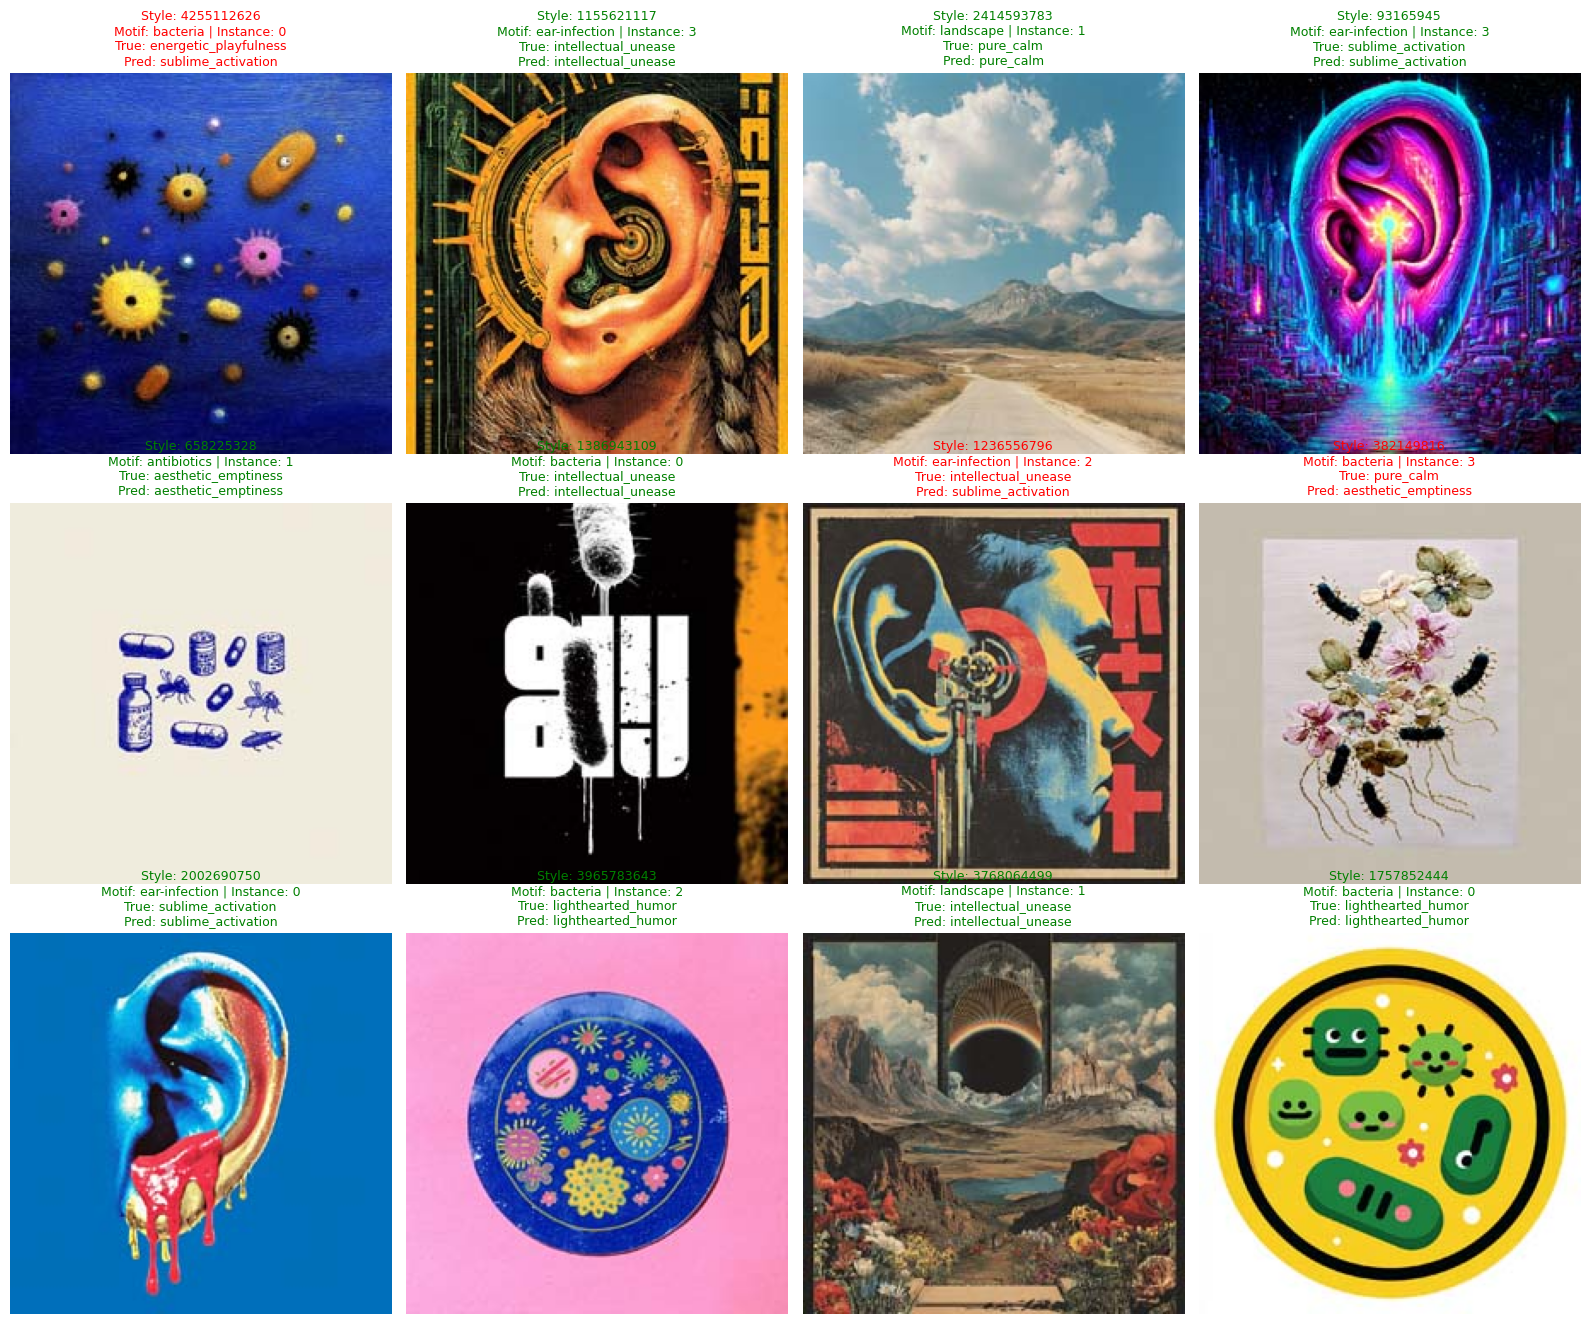

In [46]:
# Display a sample of test images with true and predicted labels.
def plot_test_predictions(test_dataset, test_metrics, label_names, num_images=12, seed=RANDOM_STATE):
    num_images = min(num_images, len(test_dataset), len(test_metrics["y_true"]))
    rng = np.random.default_rng(seed)
    sample_indices = rng.choice(len(test_dataset), size=num_images, replace=False)

    n_cols = 4
    n_rows = int(np.ceil(num_images / n_cols))
    fig, axes = plt.subplots(n_rows, n_cols, figsize=(4 * n_cols, 4.4 * n_rows))
    axes = np.array(axes).reshape(-1)

    for ax, idx in zip(axes, sample_indices):
        sample = test_dataset[int(idx)]

        style = sample["style"]
        motif = sample["motif"]
        instance = sample["instance"]

        print(
            f"Index {idx}: "
            f"style={style}, motif={motif}, instance={instance}"
        )

        image = sample["image"].convert("RGB")      
        true_label = label_names[test_metrics["y_true"][int(idx)]]
        pred_label = label_names[test_metrics["y_pred"][int(idx)]]
        is_correct = true_label == pred_label

        ax.imshow(image)
        ax.set_title(
            f"Style: {style}\n"
            f"Motif: {motif} | Instance: {instance}\n"
            f"True: {true_label}\nPred: {pred_label}",
            color="green" if is_correct else "red",
            fontsize=9,
        )
        ax.axis("off")

    for ax in axes[num_images:]:
        ax.axis("off")

    plt.tight_layout()
    plt.show()


plot_test_predictions(test_dataset, test_metrics, label_names)
